In [10]:
import xarray as xr
import numpy as np
import wrf
import matplotlib.pyplot as plt
import pandas as pd
from netCDF4 import Dataset

import metpy.calc as mpcalc
from metpy.units import units
from metpy.plots import SkewT, Hodograph, add_metpy_logo
from metpy.cbook import get_test_data

In [11]:
col_names = ['pressure', 'height', 'temperature', 'dewpoint', 'wind_direction', 'wind_speed']
df = pd.read_fwf(get_test_data("may4_sounding.txt", as_file_obj=False), skiprows=5, usecols=[0, 1,2,3,6,7], names = col_names)


In [12]:
df

,pressure,height,temperature,dewpoint,wind_direction,wind_speed
0,959.0,345,22.2,19.0,160,18
1,931.3,610,20.2,17.5,165,40
2,925.0,671,19.8,17.1,165,38
3,899.3,914,18.4,16.9,175,39
4,892.0,984,18.0,16.8,178,39
5,867.9,1219,17.4,14.3,190,38
6,850.0,1397,17.0,12.5,195,38
7,814.0,1766,15.4,5.4,204,37
8,807.9,1829,15.4,1.2,205,37
9,790.0,2019,15.6,-11.4,211,40


In [13]:
p = df["pressure"].values * units.hPa
T = df["temperature"].values * units.degC
Td = df["dewpoint"].values * units.degC
wind_speed = df["wind_speed"].values * units.knots
wind_dir = df["wind_direction"].values * units.degrees
u, v = mpcalc.wind_components(wind_speed, wind_dir)

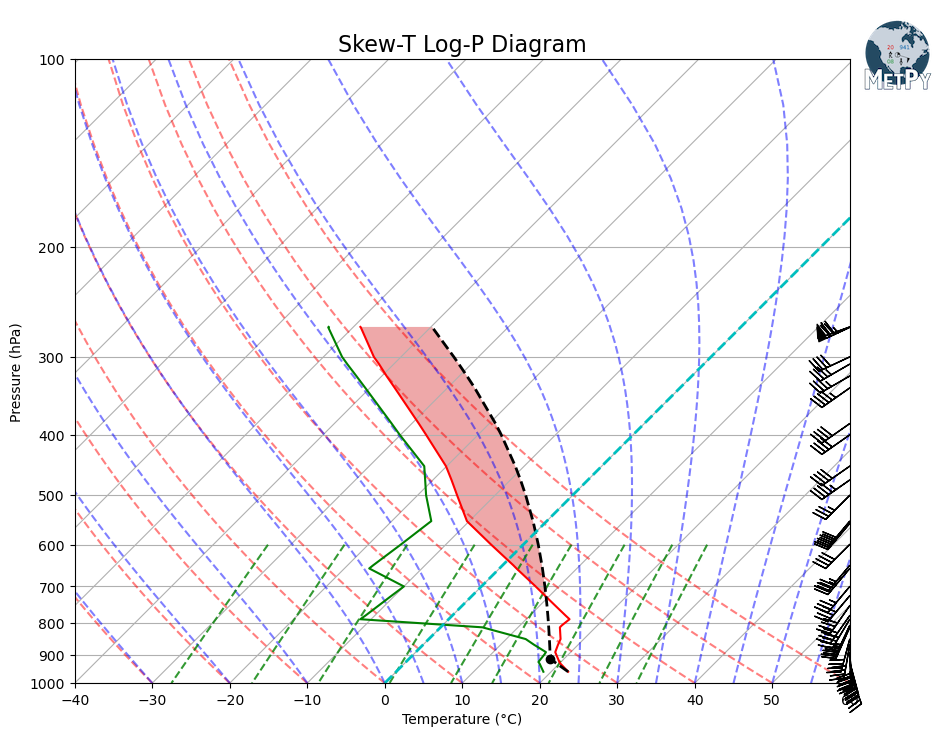

In [14]:
fig = plt.figure(figsize=(10, 15))
add_metpy_logo(fig, 860, 650)
skew = SkewT(fig, rotation=45)

skew.plot(p, T, 'r')
skew.plot(p, Td, 'g')
skew.plot_barbs(p, u, v)
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 60)

lcl_pressure, lcl_temperature = mpcalc.lcl(p[0], T[0], Td[0])
skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='black')

prof = mpcalc.parcel_profile(p, T[0], Td[0]).to('degC')
skew.plot(p, prof, 'k', linewidth=2, linestyle='--')

skew.shade_cin(p, T, prof, Td)
skew.shade_cape(p, T, prof)

skew.ax.axvline(0, color='c', linewidth=2, linestyle='--')

skew.plot_dry_adiabats()
skew.plot_moist_adiabats()
skew.plot_mixing_lines()

skew.ax.set_xlabel('Temperature (°C)')
skew.ax.set_ylabel('Pressure (hPa)')

skew.ax.set_title('Skew-T Log-P Diagram', fontsize=16)

plt.show()

# FOR NAIROBI :: 2026/06/03 - 2026/06/04

In [15]:
ncfile = Dataset("/home/erickwambugu/WRF/run/wrfout_d01_2026-06-03_00:00:00")

In [ ]:
# define our locations to draw the skewT in a dictionary
locations = {
    "Nairobi": {"lat": -1.2921, "lon": 36.8219},
    "Mombasa": {"lat": -4.0435, "lon": 39.6682},
    "Kisumu": {"lat": -0.0917, "lon": 34.7678},
    "Nakuru": {"lat": -0.3031, "lon": 36.0800}
}

In [27]:
# loop through the locations and draw the skewT for each location
for location, coords in locations.items():
    x_y = wrf.ll_to_xy(ncfile, coords["lat"], coords["lon"])

    for t in range(ncfile.dimensions['Time'].size):
        p = wrf.getvar(ncfile, "pressure", timeidx=t)[:, x_y[1], x_y[0]] * units.hPa
        T = wrf.getvar(ncfile, "tc", timeidx=t)[:, x_y[1], x_y[0]] - 273.15 * units.degC
        Td = wrf.getvar(ncfile, "td", timeidx=t)[:, x_y[1], x_y[0]] - 273.15 * units.degC
        wind_speed = wrf.getvar(ncfile, "ua", timeidx=t)[:, x_y[1], x_y[0]] * units.knots
        wind_dir = wrf.getvar(ncfile, "va", timeidx=t)[:, x_y[1], x_y[0]] * units.degrees
        u, v = mpcalc.wind_components(wind_speed, wind_dir)

        fig = plt.figure(figsize=(10, 15))
        add_metpy_logo(fig, 860, 650)
        skew = SkewT(fig, rotation=45)

        skew.plot(p, T, 'r')
        skew.plot(p, Td, 'g')
        skew.plot_barbs(p, u, v)
        skew.ax.set_ylim(1000, 100)
        skew.ax.set_xlim(-40, 60)

        lcl_pressure, lcl_temperature = mpcalc.lcl(p[0], T[0], Td[0])
        skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='black')

        prof = mpcalc.parcel_profile(p, T[0], Td[0]).to('degC')
        skew.plot(p, prof, 'k', linewidth=2, linestyle='--')

        skew.shade_cin(p, T, prof, Td)
        skew.shade_cape(p, T, prof)

        skew.ax.axvline(0, color='c', linewidth=2, linestyle='--')

        skew.plot_dry_adiabats()
        skew.plot_moist_adiabats()
        skew.plot_mixing_lines()

        skew.ax.set_xlabel('Temperature (°C)')
        skew.ax.set_ylabel('Pressure (hPa)')

        skew.ax.set_title(f'Skew-T Log-P Diagram for {location} at Time Index {t}', fontsize=16)

        plt.show()

DimensionalityError: Cannot convert from 'dimensionless' to 'degree_Celsius'